# LDA vs Logistic Regression -- Built From Scratch
## Binary Classification, One Feature (p=1, K=2)

**Dataset:** Wisconsin Breast Cancer -- single feature `radius_mean`, target: Benign / Malignant  
**Goal:** Implement both classifiers from their mathematical definitions, compare decision boundaries.

---

### Mathematical foundation

**Logistic Regression** models the posterior directly:
$$P(Y=1 \mid X=x) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x)}}$$
Coefficients are found by maximizing the log-likelihood via gradient ascent.

**LDA** models class-conditional densities, then applies Bayes' theorem:
$$P(Y=k \mid X=x) \propto \pi_k \cdot f_k(x), \quad f_k(x) = \mathcal{N}(x; \mu_k, \sigma^2)$$
Parameters are estimated directly from data -- no optimization loop needed.

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.datasets import load_breast_cancer

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

## 1. Data -- One Real Feature

We use `radius_mean` (mean radius of the tumor) from the Wisconsin Breast Cancer dataset.  
Chosen because it has strong but imperfect separation -- both models have something interesting to do.  
Real data means no controlled variance: both models deal with the actual distribution.

We flip the sklearn encoding so **y=1 = malignant** (positive class) -- consistent with medical convention.

In [4]:
raw = load_breast_cancer(as_frame=True)
df  = raw.frame.rename(columns={'target': 'y'})
df['y'] = 1 - df['y']   # sklearn: 1=benign, 0=malignant -- flip to y=1=malignant

X  = df['mean radius'].values
y  = df['y'].values
X0 = X[y == 0]   # benign
X1 = X[y == 1]   # malignant

print(f'Samples   : {len(X)} total  |  {(y==0).sum()} benign  |  {(y==1).sum()} malignant')
print(f'radius_mean range  : [{X.min():.2f}, {X.max():.2f}]')
print(f'Benign mean        : {X0.mean():.2f}  +/-{X0.std():.2f}')
print(f'Malignant mean     : {X1.mean():.2f}  +/-{X1.std():.2f}')

Samples   : 569 total  |  357 benign  |  212 malignant
radius_mean range  : [6.98, 28.11]
Benign mean        : 12.15  +/-1.78
Malignant mean     : 17.46  +/-3.20


## 2. Exploratory Look

Two questions before modelling:
1. Are the classes separable on this one feature?
2. Do within-class distributions look approximately Gaussian? (LDA's core assumption)

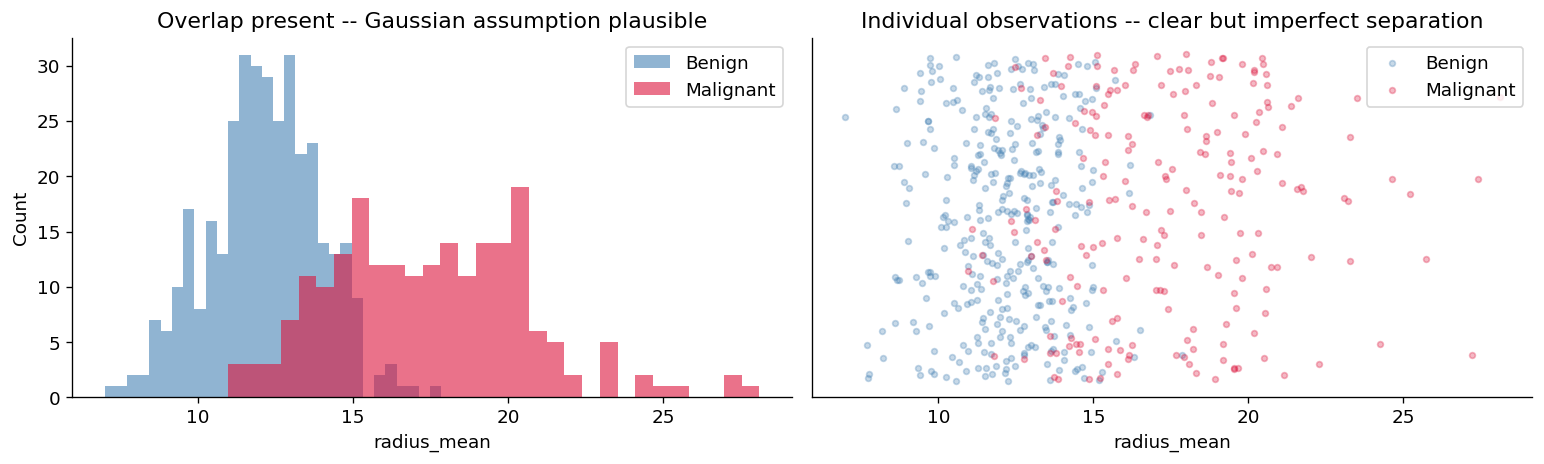

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.hist(X0, bins=30, alpha=0.6, color='steelblue', label='Benign')
ax.hist(X1, bins=30, alpha=0.6, color='crimson',   label='Malignant')
ax.set_xlabel('radius_mean')
ax.set_ylabel('Count')
ax.set_title('Overlap present -- Gaussian assumption plausible')
ax.legend()

ax = axes[1]
np.random.seed(42)
jitter = lambda n: np.random.uniform(-0.2, 0.2, n)
ax.scatter(X0, jitter(len(X0)), alpha=0.3, s=12, color='steelblue', label='Benign')
ax.scatter(X1, jitter(len(X1)), alpha=0.3, s=12, color='crimson',   label='Malignant')
ax.set_xlabel('radius_mean')
ax.set_yticks([])
ax.set_title('Individual observations -- clear but imperfect separation')
ax.legend()
plt.tight_layout()
plt.show()

## 3. LDA From Scratch

### What we estimate

| Parameter | Formula | Meaning |
|---|---|---|
| $\hat{\mu}_k$ | $\frac{1}{n_k}\sum_{i:y_i=k} x_i$ | Mean of class k |
| $\hat{\sigma}^2$ | $\frac{1}{n-K}\sum_k\sum_{i:y_i=k}(x_i - \hat{\mu}_k)^2$ | Pooled within-class variance |
| $\hat{\pi}_k$ | $n_k / n$ | Prior probability of class k |

### Decision rule

Assign to class k maximising:
$$\hat{\delta}_k(x) = x \cdot \frac{\hat{\mu}_k}{\hat{\sigma}^2} - \frac{\hat{\mu}_k^2}{2\hat{\sigma}^2} + \log(\hat{\pi}_k)$$

### Analytical boundary

Set $\hat{\delta}_0(x) = \hat{\delta}_1(x)$ and solve:
$$x^* = \frac{\hat{\mu}_0 + \hat{\mu}_1}{2} - \hat{\sigma}^2 \cdot \frac{\log(\hat{\pi}_1/\hat{\pi}_0)}{\hat{\mu}_1 - \hat{\mu}_0}$$

> When $\pi_0 = \pi_1$ the log term vanishes and the boundary is the midpoint between means.

In [7]:
class LDA:
    
    def fit(self, X, y):
        classes   = np.unique(y)
        n         = len(y)
        self.mu_  = {}
        self.pi_  = {}

        # Step 1: class means and priors
        for k in classes:
            Xk           = X[y == k]
            self.mu_[k]  = Xk.mean()       # mu_hat_k
            self.pi_[k]  = len(Xk) / n     # pi_hat_k

        # Step 2: pooled within-class variance (shared sigma^2)
        # Divide by (n - K) not (n - 1): Bessel correction across all classes
        K = len(classes)
        pooled_ss = sum(
            ((X[y == k] - self.mu_[k]) ** 2).sum()
            for k in classes
        )
        self.sigma2_ = pooled_ss / (n - K)

        # Step 3: analytical decision boundary (set delta0 = delta1, solve for x)
        mu0, mu1 = self.mu_[0], self.mu_[1]
        pi0, pi1 = self.pi_[0], self.pi_[1]
        self.boundary_ = (
            (mu0 + mu1) / 2
            - self.sigma2_ * np.log(pi1 / pi0) / (mu1 - mu0)
        )
        return self

    def discriminant(self, x, k):
        # delta_k(x): higher -> more likely class k
        return (x * self.mu_[k] / self.sigma2_
                - self.mu_[k]**2 / (2 * self.sigma2_)
                + np.log(self.pi_[k]))

    def predict_proba(self, X):
        # Posterior P(Y=1|X) via Bayes (softmax of discriminants)
        d0 = self.discriminant(X, 0)
        d1 = self.discriminant(X, 1)
        return np.exp(d1) / (np.exp(d0) + np.exp(d1))

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)


lda = LDA().fit(X, y)

print('-- LDA estimates ------------------------------------------')
print(f'  mu_hat (benign)    = {lda.mu_[0]:.4f}')
print(f'  mu_hat (malignant) = {lda.mu_[1]:.4f}')
print(f'  sigma^2_hat        = {lda.sigma2_:.4f}')
print(f'  pi_hat (benign)    = {lda.pi_[0]:.4f}')
print(f'  pi_hat (malignant) = {lda.pi_[1]:.4f}')
print(f'  Decision boundary  = {lda.boundary_:.4f}')

-- LDA estimates ------------------------------------------
  mu_hat (benign)    = 12.1465
  mu_hat (malignant) = 17.4628
  sigma^2_hat        = 5.8106
  pi_hat (benign)    = 0.6274
  pi_hat (malignant) = 0.3726
  Decision boundary  = 15.3743


## 4. Logistic Regression From Scratch

### What we optimize

Find $\beta_0, \beta_1$ by maximizing the log-likelihood:
$$\ell(\beta) = \sum_{i=1}^n \left[ y_i \log p_i + (1 - y_i) \log(1 - p_i) \right]$$

Gradient ascent update at each step:
$$\nabla_{\beta_0} \ell = \sum_i (y_i - p_i), \quad \nabla_{\beta_1} \ell = \sum_i (y_i - p_i) x_i$$

### Decision boundary

Where $P(Y=1|x) = 0.5$, i.e. $\beta_0 + \beta_1 x = 0$:
$$x^* = -\beta_0 / \beta_1$$

> **Note:** Gradient ascent is scale-sensitive. We standardize X first, then convert the boundary back to original units.

In [8]:
class LogisticRegressionScratch:

    def __init__(self, lr=0.1, n_iter=3000):
        self.lr     = lr
        self.n_iter = n_iter

    @staticmethod
    def _sigmoid(z):
        return 1 / (1 + np.exp(-np.clip(z, -250, 250)))

    def fit(self, X, y):
        self.beta0_ = 0.0
        self.beta1_ = 0.0
        self.loss_history_ = []

        for _ in range(self.n_iter):
            z     = self.beta0_ + self.beta1_ * X
            p     = self._sigmoid(z)

            # Log-likelihood for tracking
            eps = 1e-12
            ll  = (y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps)).mean()
            self.loss_history_.append(ll)

            # Gradients of log-likelihood
            resid       = y - p
            self.beta0_ += self.lr * resid.mean()
            self.beta1_ += self.lr * (resid * X).mean()

        # Decision boundary in standardized space, then convert back
        self.boundary_std_ = -self.beta0_ / self.beta1_
        return self

    def predict_proba(self, X):
        return self._sigmoid(self.beta0_ + self.beta1_ * X)

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)


# Standardize X (gradient ascent is scale-sensitive)
X_mean, X_std = X.mean(), X.std(ddof=0)
Xs = (X - X_mean) / X_std

lr_model = LogisticRegressionScratch(lr=0.1, n_iter=3000).fit(Xs, y)

# Convert boundary from standardized space back to original radius_mean scale
lr_boundary = lr_model.boundary_std_ * X_std + X_mean

print('-- Logistic Regression estimates --------------------------')
print(f'  beta0 (std space) = {lr_model.beta0_:.4f}')
print(f'  beta1 (std space) = {lr_model.beta1_:.4f}')
print(f'  Decision boundary = {lr_boundary:.4f}')
print(f'  Final log-likelihood = {lr_model.loss_history_[-1]:.4f}')

-- Logistic Regression estimates --------------------------
  beta0 (std space) = -0.6440
  beta1 (std space) = 3.6298
  Decision boundary = 14.7520
  Final log-likelihood = -0.2900


### Convergence check

Log-likelihood should increase monotonically and plateau -- confirming gradient ascent converged.

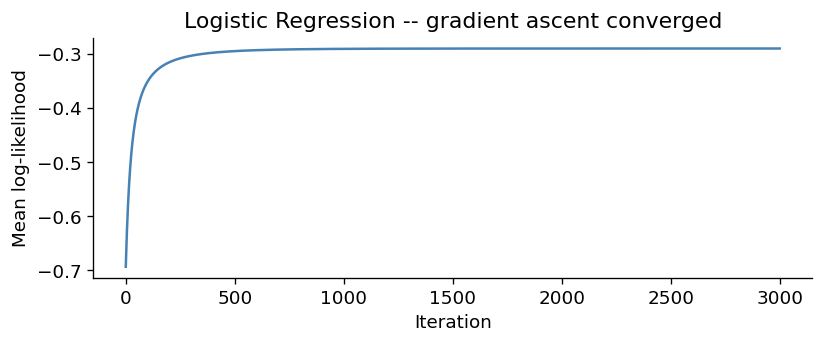

In [9]:
plt.figure(figsize=(7, 3))
plt.plot(lr_model.loss_history_, color='steelblue', linewidth=1.5)
plt.xlabel('Iteration')
plt.ylabel('Mean log-likelihood')
plt.title('Logistic Regression -- gradient ascent converged')
plt.tight_layout()
plt.show()

## 5. Decision Boundaries & Posterior Probabilities

Three things to compare:
1. **Where each model draws the boundary** -- are they in the same place?
2. **How confident each model is** -- how fast does P(Y=1|x) rise from 0 to 1?
3. **The LDA Gaussian fits** -- do they match the real histograms?

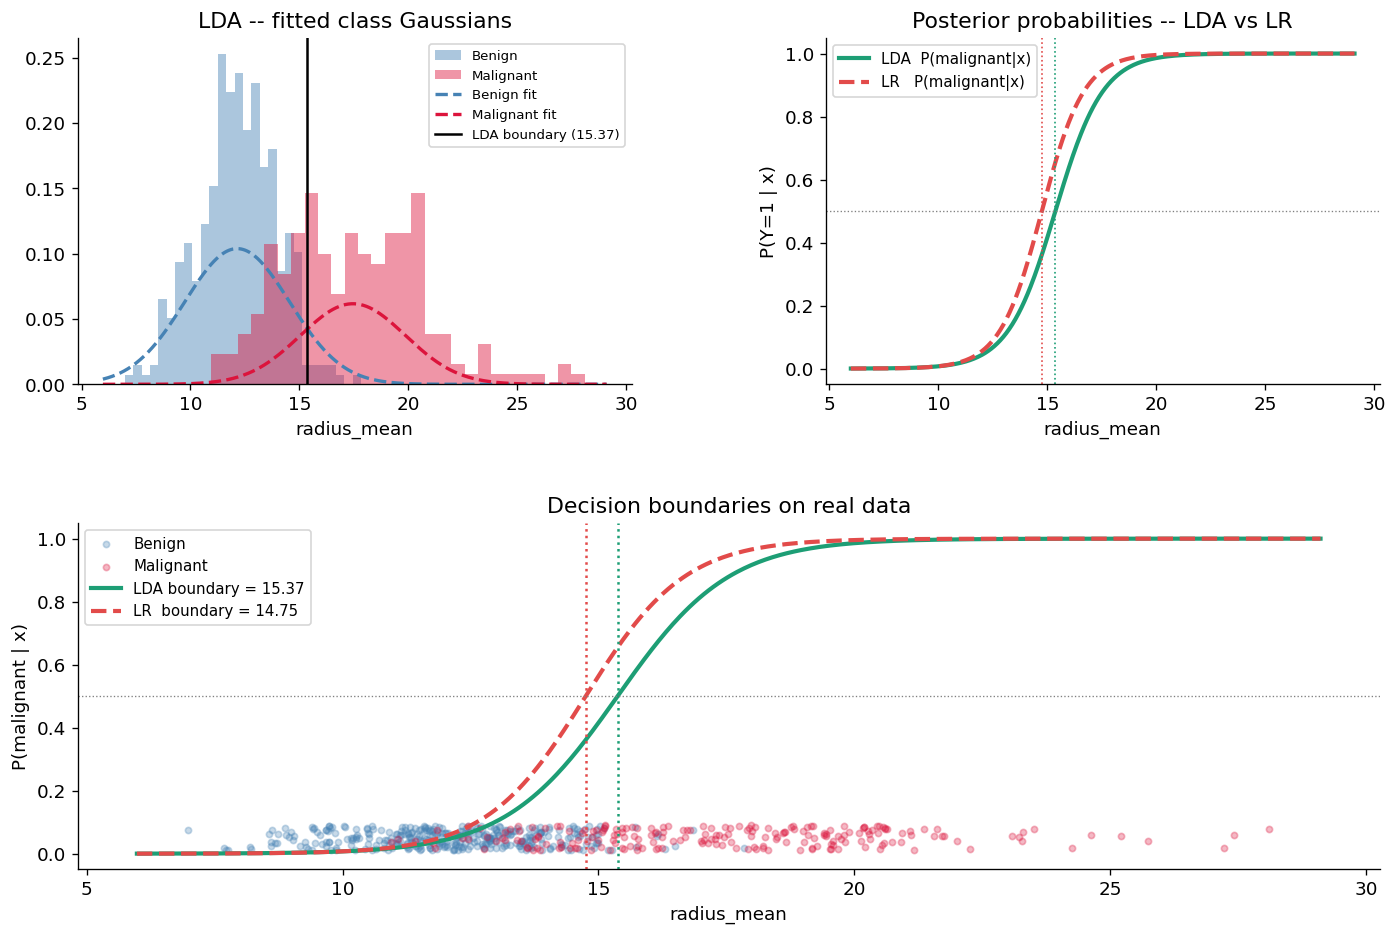

LDA boundary : 15.3743
LR  boundary : 14.7520
Gap          : 0.6223


In [11]:
xgrid   = np.linspace(X.min() - 1, X.max() + 1, 500)
xgrid_s = (xgrid - X_mean) / X_std

prob_lda = lda.predict_proba(xgrid)
prob_lr  = lr_model.predict_proba(xgrid_s)

fig = plt.figure(figsize=(14, 9))
gs  = gridspec.GridSpec(2, 2, hspace=0.4, wspace=0.35)

# Top-left: histograms + LDA Gaussian fits
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(X0, bins=28, density=True, alpha=0.45, color='steelblue', label='Benign')
ax1.hist(X1, bins=28, density=True, alpha=0.45, color='crimson',   label='Malignant')
sigma = np.sqrt(lda.sigma2_)
for k, col, lbl in [(0,'steelblue','Benign fit'),(1,'crimson','Malignant fit')]:
    gauss = (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((xgrid-lda.mu_[k])/sigma)**2)
    ax1.plot(xgrid, gauss * lda.pi_[k], color=col, linewidth=2, linestyle='--', label=lbl)
ax1.axvline(lda.boundary_, color='black', linewidth=1.5, label=f'LDA boundary ({lda.boundary_:.2f})')
ax1.set_xlabel('radius_mean')
ax1.set_title('LDA -- fitted class Gaussians')
ax1.legend(fontsize=8)

# Top-right: posterior probabilities
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(xgrid, prob_lda, color='#1D9E75', linewidth=2.5, label='LDA  P(malignant|x)')
ax2.plot(xgrid, prob_lr,  color='#E24B4A', linewidth=2.5, linestyle='--', label='LR   P(malignant|x)')
ax2.axhline(0.5, color='gray', linewidth=0.8, linestyle=':')
ax2.axvline(lda.boundary_, color='#1D9E75', linewidth=1, linestyle=':')
ax2.axvline(lr_boundary,   color='#E24B4A', linewidth=1, linestyle=':')
ax2.set_xlabel('radius_mean')
ax2.set_ylabel('P(Y=1 | x)')
ax2.set_title('Posterior probabilities -- LDA vs LR')
ax2.legend(fontsize=9)

# Bottom: full comparison with data
ax3 = fig.add_subplot(gs[1, :])
np.random.seed(42)
jf = lambda n: np.full(n, 0.05) + np.random.uniform(-0.04, 0.04, n)
ax3.scatter(X0, jf(len(X0)), alpha=0.3, s=14, color='steelblue', label='Benign')
ax3.scatter(X1, jf(len(X1)), alpha=0.3, s=14, color='crimson',   label='Malignant')
ax3.plot(xgrid, prob_lda, color='#1D9E75', linewidth=2.5, label=f'LDA boundary = {lda.boundary_:.2f}')
ax3.plot(xgrid, prob_lr,  color='#E24B4A', linewidth=2.5, linestyle='--', label=f'LR  boundary = {lr_boundary:.2f}')
ax3.axvline(lda.boundary_, color='#1D9E75', linewidth=1.5, linestyle=':')
ax3.axvline(lr_boundary,   color='#E24B4A', linewidth=1.5, linestyle=':')
ax3.axhline(0.5, color='gray', linewidth=0.8, linestyle=':')
ax3.set_xlabel('radius_mean')
ax3.set_ylabel('P(malignant | x)')
ax3.set_title('Decision boundaries on real data')
ax3.legend(fontsize=9)
plt.show()

print(f'LDA boundary : {lda.boundary_:.4f}')
print(f'LR  boundary : {lr_boundary:.4f}')
print(f'Gap          : {abs(lda.boundary_ - lr_boundary):.4f}')

## 6. Performance Comparison

Evaluated on the full dataset (no split -- this is about understanding the models, not production evaluation).  
The interesting number is not which model scores higher, but **where they disagree**.

In [10]:
from sklearn.metrics import accuracy_score, recall_score, precision_score

Xs_all = (X - X_mean) / X_std
y_lda  = lda.predict(X)
y_lr   = lr_model.predict(Xs_all)

disagree = np.where(y_lda != y_lr)[0]

print(f'{'Metric':<26} {'LDA':>10} {'LR':>10}')
print('-' * 48)
for label, fn in [
    ('Accuracy',              accuracy_score),
    ('Recall (malignant)',    lambda yt,yp: recall_score(yt,yp,pos_label=1)),
    ('Precision (malignant)', lambda yt,yp: precision_score(yt,yp,pos_label=1)),
]:
    print(f'{label:<26} {fn(y, y_lda):>10.4f} {fn(y, y_lr):>10.4f}')

print(f'\nSamples where LDA != LR : {len(disagree)} / {len(y)}  ({len(disagree)/len(y)*100:.1f}%)')
print(f'  radius_mean at disagreements: {X[disagree].round(2)}')

Metric                            LDA         LR
------------------------------------------------
Accuracy                       0.8752     0.8787
Recall (malignant)             0.7028     0.7877
Precision (malignant)          0.9490     0.8743

Samples where LDA != LR : 34 / 569  (6.0%)
  radius_mean at disagreements: [15.34 15.3  14.99 15.1  14.78 15.37 15.06 14.87 15.1  14.95 14.95 14.97
 14.97 15.28 14.86 15.12 15.27 15.   15.32 14.96 14.76 15.08 15.19 14.99
 15.13 14.9  14.86 14.8  14.92 14.87 15.04 14.81 15.05 15.22]


## 7. Key Observations

### Why the boundaries are close but not identical

LDA boundary comes directly from plugging $\hat{\mu}_k$, $\hat{\sigma}^2$, $\hat{\pi}_k$ into the closed-form formula.  
LR boundary comes from gradient ascent maximizing the log-likelihood -- no Gaussian assumption.  
When the Gaussian assumption approximately holds (as here), both find nearly the same boundary.  
The small gap reflects LR fitting the actual data shape vs LDA fitting two Gaussians.

### Why the posterior curves differ

LDA's curve rises at a rate fixed by $\sigma^2$ (pooled variance).  
LR's sigmoid slope is determined by $\beta_1$ -- fitted directly to the data.  
LR's curve is often steeper if the real transition is sharper than the Gaussian model predicts.

### The separation problem (ISLR section 4.4)

This dataset has moderate overlap -- not perfect separation.  
To observe LR's MLE divergence problem: filter to only extreme radius_mean values  
(e.g. only rows where radius_mean < 11 or > 18). LR coefficients will grow very large  
while LDA remains stable. That is the natural next experiment to run.

### Extending this notebook

- Add QDA (class-specific $\sigma^2_k$ instead of pooled) and compare the three boundaries  
- Add a train/test split and proper evaluation  
- Extend to p=2 features and visualize the 2D decision boundary  
- Force perfect separation and watch LR fail while LDA stays stable